
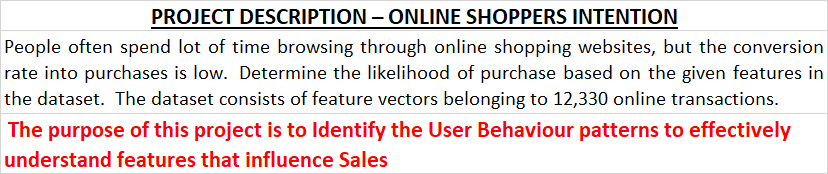

## FEATURE ANALYSIS

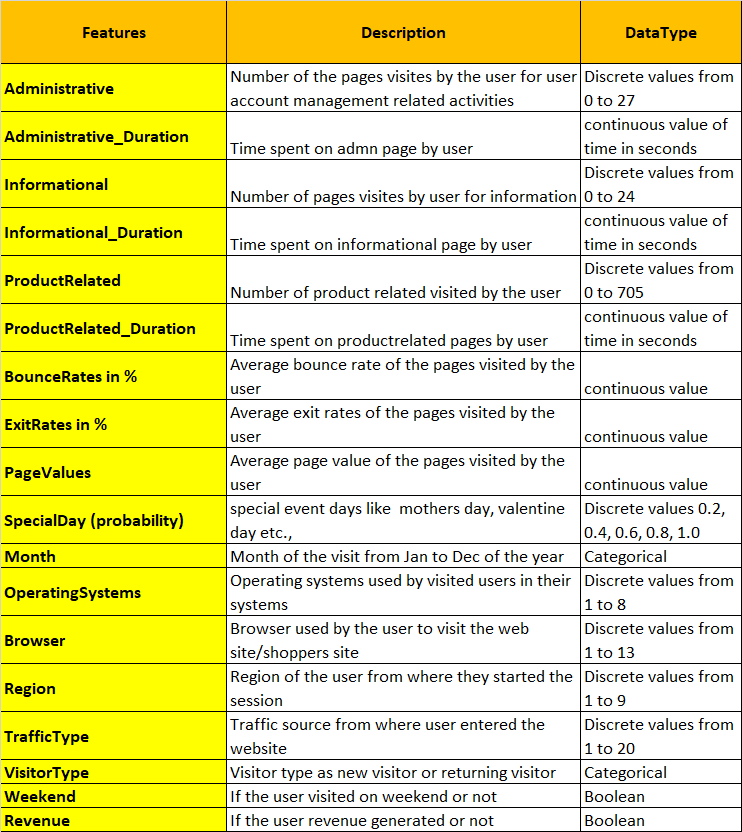


In [1]:
# Import basic libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# import warnings to ignore unnecessary warnings 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("~/Downloads/online_shoppers_intention.csv")
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates in %,ExitRates in %,PageValues,SpecialDay (probability),Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [3]:
df.shape

(12330, 18)

In [4]:
df.info()

# there are total 18 features in the dataset out of which one feature i.e., Revenue feature is Target variable. 
# Rest 17 features are Predictive variable.
# 7 features are numerical discrete variables.
# 7 features are numerical continuous variables. We need to apply scaling on these numerical features if required
# 2 features are categorical and 2 features are boolean variables. We need to convert them to numerical or get dummies.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Administrative            12330 non-null  int64  
 1   Administrative_Duration   12330 non-null  float64
 2   Informational             12330 non-null  int64  
 3   Informational_Duration    12330 non-null  float64
 4   ProductRelated            12330 non-null  int64  
 5   ProductRelated_Duration   12330 non-null  float64
 6   BounceRates in %          12330 non-null  float64
 7   ExitRates in %            12330 non-null  float64
 8   PageValues                12330 non-null  float64
 9   SpecialDay (probability)  12330 non-null  float64
 10  Month                     12330 non-null  object 
 11  OperatingSystems          12330 non-null  int64  
 12  Browser                   12330 non-null  int64  
 13  Region                    12330 non-null  int64  
 14  Traffi

In [63]:
# Label encoding of Revenue

from sklearn.preprocessing import LabelEncoder



In [64]:
le = LabelEncoder()
df['Revenue'] = le.fit_transform(df['Revenue'])
df['Revenue'].value_counts()

0    10422
1     1908
Name: Revenue, dtype: int64

In [65]:
# splitting the dependent and independent variable columns

X = df.drop(['Revenue'], axis = 1)
y = df['Revenue']

In [7]:
df.corr()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates in %,ExitRates in %,PageValues,SpecialDay (probability),OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue
Administrative,1.000000,0.601583,0.376850,0.255848,0.431119,0.373939,-0.223563,-0.316483,0.098990,-0.094778,-0.006347,-0.025035,-0.005487,-0.033561,0.026417,0.138917
Administrative_Duration,0.601583,1.000000,0.302710,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608,-0.073304,-0.007343,-0.015392,-0.005561,-0.014376,0.014990,0.093587
Informational,0.376850,0.302710,1.000000,0.618955,0.374164,0.387505,-0.116114,-0.163666,0.048632,-0.048219,-0.009527,-0.038235,-0.029169,-0.034491,0.035785,0.095200
Informational_Duration,0.255848,0.238031,0.618955,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861,-0.030577,-0.009579,-0.019285,-0.027144,-0.024675,0.024078,0.070345
ProductRelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958,0.004290,-0.013146,-0.038122,-0.043064,0.016092,0.158538
ProductRelated_Duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380,0.002976,-0.007380,-0.033091,-0.036377,0.007311,0.152373
BounceRates in %,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702,0.023823,-0.015772,-0.006485,0.078286,-0.046514,-0.150673
ExitRates in %,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242,0.014567,-0.004442,-0.008907,0.078616,-0.062587,-0.207071
PageValues,0.098990,0.067608,0.048632,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000,-0.063541,0.018508,0.045592,0.011315,0.012532,0.012002,0.492569
SpecialDay (probability),-0.094778,-0.073304,-0.048219,-0.030577,-0.023958,-0.036380,0.072702,0.102242,-0.063541,1.000000,0.012652,0.003499,-0.016098,0.052301,-0.016767,-0.082305


<AxesSubplot: >

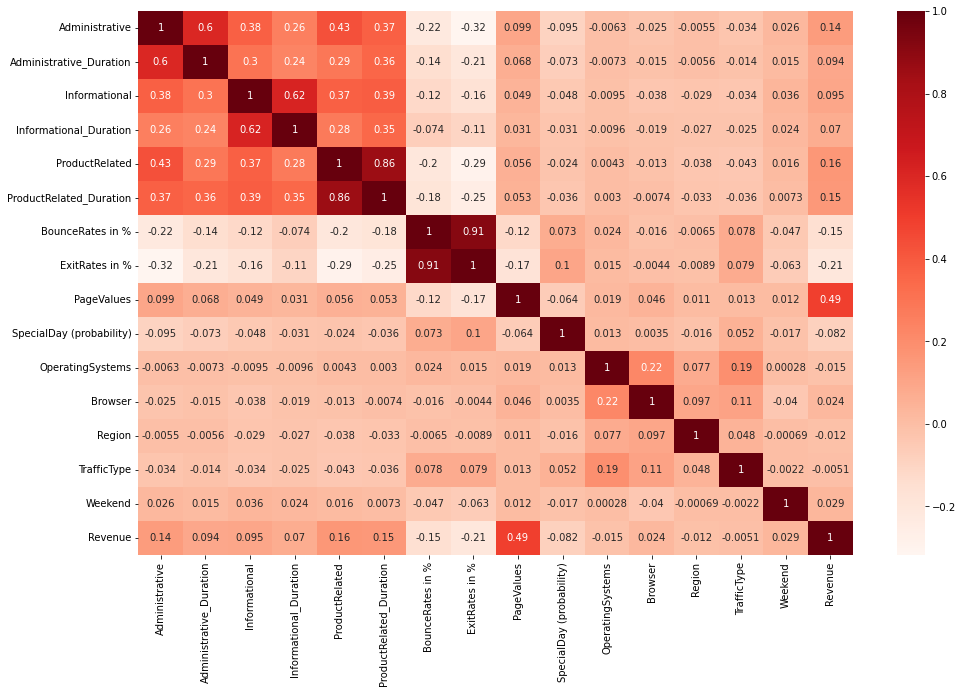

In [8]:
plt.figure(figsize = (16,10))
sns.heatmap(data = df.corr(), cmap = 'Reds', annot = True)

In [ ]:
# OBSERVATIONS ON CORRELATION AND HEAT MAP
# Based on above correlation and heat map observations it is found that only Page values have relation with Revenue
# There is a slight relation observed with Product related and Admn related features with Revenue.
# There is also multicollinearity observed between Bouncerates and Exitrates.

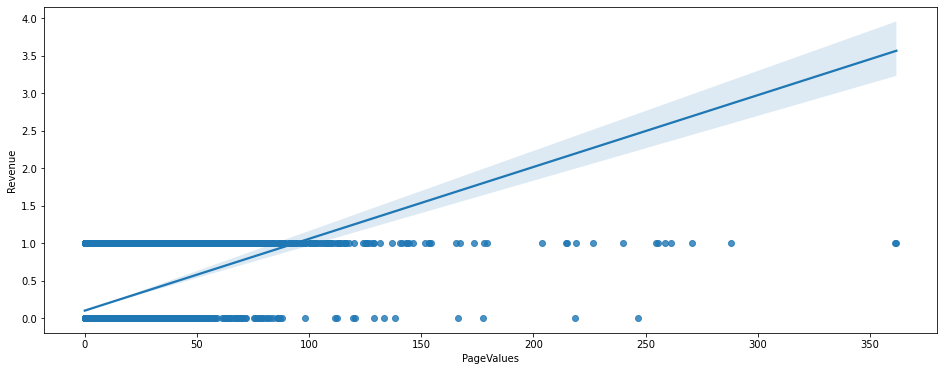

In [9]:
plt.figure(figsize = (16,6))
sns.regplot(x= 'PageValues', y = 'Revenue' , data = df)
plt.show()

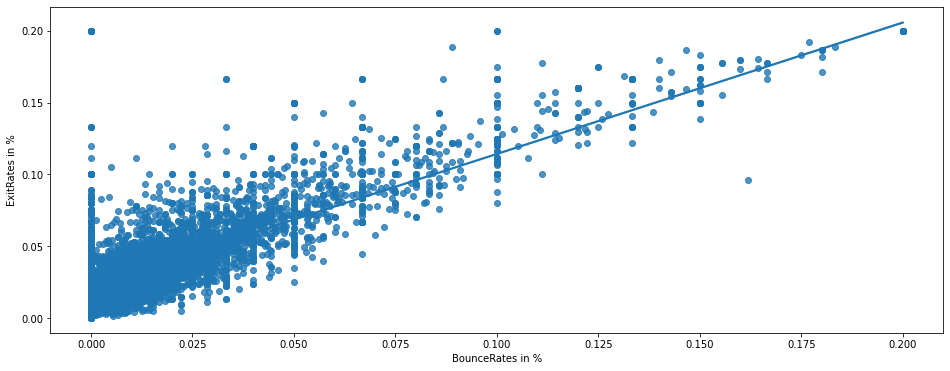

In [10]:
plt.figure(figsize = (16,6))
sns.regplot(x= 'BounceRates in %', y = 'ExitRates in %' , data = df)
plt.show()

# TARGET ANALYSIS

In [11]:
df['Revenue'].value_counts(normalize = True)

# Shows 84.5% of page visits not converted to Revenue
# Only 14.5% of page visits converted to Revenue

# Series.value_counts(normalize=False, sort=True, ascending=False, bins=None, dropna=True)[source]


False    0.845255
True     0.154745
Name: Revenue, dtype: float64

<AxesSubplot: xlabel='Revenue', ylabel='count'>

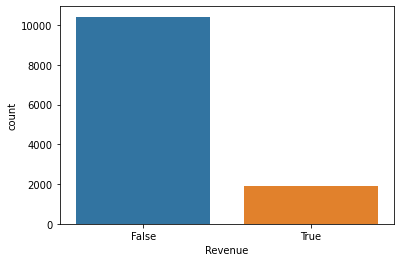

In [12]:
# plotting count plot for Revenue for better visualization
sns.countplot(data = df, x = 'Revenue')

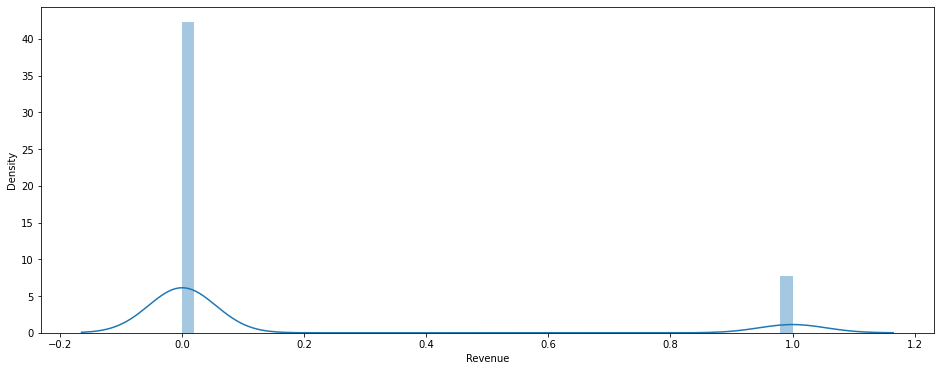

In [13]:
#plot the Revenue
plt.figure(figsize = (16,6))
sns.distplot(df['Revenue'])
plt.show()

# A Distplot or distribution plot, depicts the variation in the data distribution. Seaborn Distplot represents the 
# overall distribution of continuous data variables. The Seaborn module along with the Matplotlib module is used to 
# depict the distplot with different variations in it.

# Kernel Density Estimation (KDE) is a way to estimate the probability density function of a continuous random variable.
# It is used for non-parametric analysis. Setting the hist flag to False in distplot will yield the kernel density 
# estimation plot. kde function is used to plot the data against a single/univariate variable.

In [14]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates in %', 'ExitRates in %', 'PageValues',
       'SpecialDay (probability)', 'Month', 'OperatingSystems', 'Browser',
       'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue'],
      dtype='object')

# Univariate Analysis of numerical discrete features


Weekend

Operating System

Browser

Month

VistorType

TrafficType

Region

In [15]:
df['Weekend'].value_counts(normalize = True)

# Only 23% page visits happened in weekends
# Rest of 77% visits happened in other days.

False    0.767397
True     0.232603
Name: Weekend, dtype: float64

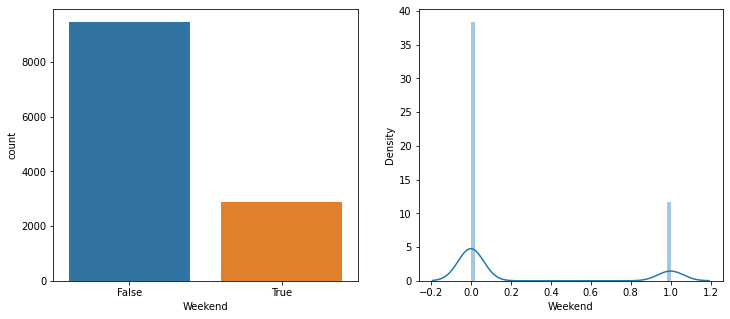

In [16]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.countplot(data = df, x = 'Weekend' )
plt.subplot(1,2,2)
sns.distplot(df['Weekend'])
plt.show()


In [17]:
df['Month'].value_counts(normalize = True)

# It is observed that May leading with 27% page visits followed by Nov with 24% 
# Next level observed with March and December with 15% and 14% page visits rest of the month negligible.

May     0.272830
Nov     0.243147
Mar     0.154663
Dec     0.140065
Oct     0.044526
Sep     0.036334
Aug     0.035118
Jul     0.035036
June    0.023358
Feb     0.014923
Name: Month, dtype: float64

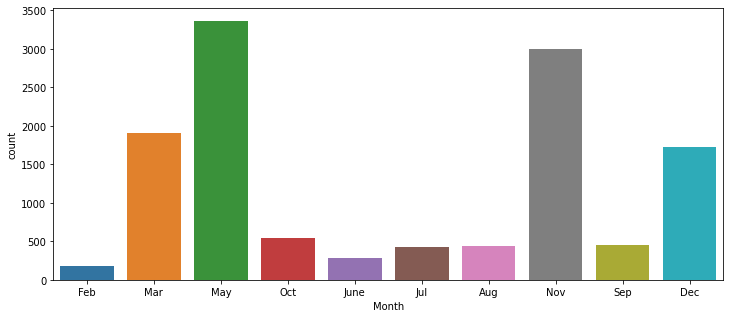

In [18]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
#plt.subplot(1,2,1)
sns.countplot(data = df, x = 'Month')
#plt.subplot(1,2,2)
#plt.pie(df['Month'])
plt.show()

# It is observed that maximum page visits happened in May, Nov, Dec and Mar months.
# Highest Revenue generated page visits happened in Nov month and then in May month.

In [19]:
df['OperatingSystems'].value_counts(normalize = True)

# It is observed that OS2 leading with 53.5% page visits followed by 1,3 OS  with 20% each.
# Rest of the operating systems effect is negligible.

2    0.535361
1    0.209651
3    0.207218
4    0.038767
8    0.006407
6    0.001541
7    0.000568
5    0.000487
Name: OperatingSystems, dtype: float64

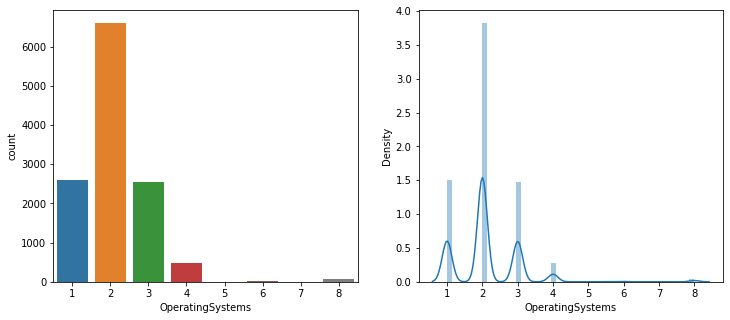

In [20]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.countplot(data = df, x = 'OperatingSystems')
plt.subplot(1,2,2)
sns.distplot(df['OperatingSystems'])
plt.show()

# Maximum page visits and Revenue generated page visits observed from user used operating system 2
# Next level of page visits and Revenue generated page visits observed from users used operating systems 1,3
# There is no significant observations from other operating systems.

In [21]:
df['Browser'].value_counts(normalize = True)

# It is observed that Browser 2 leading with 65% page visits followed by Browser 1 with 20% 
# page visits from rest of the browsers is negligible.

2     0.645661
1     0.199676
4     0.059692
5     0.037875
6     0.014112
10    0.013220
8     0.010949
3     0.008516
13    0.004947
7     0.003974
12    0.000811
11    0.000487
9     0.000081
Name: Browser, dtype: float64

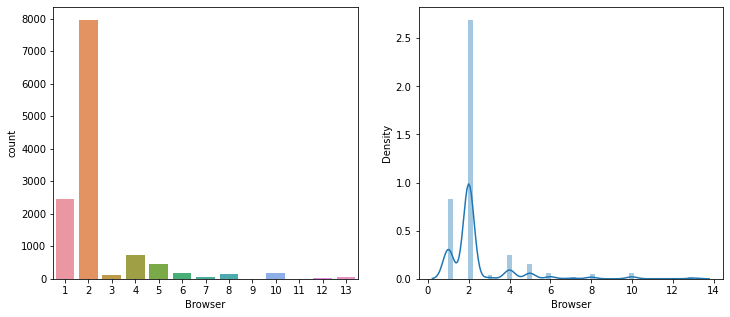

In [22]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.countplot(data = df, x = 'Browser')
plt.subplot(1,2,2)
sns.distplot(df['Browser'])
plt.show()

# Highest page visits and revenue generated page visits observed from Browser 2
# Followed by page visits of Browsers 1, 4,5 some level of page visits observed.

In [23]:
df['Region'].value_counts(normalize = True)

# It is observed that Region 1 leading with 39% page visits followed by 3 with 20% 
# Next level observed with Regions 4 and 2 with 9% each page visits rest of the regions contribution is not considerable.

1    0.387672
3    0.194891
4    0.095864
2    0.092133
6    0.065288
7    0.061719
9    0.041444
8    0.035199
5    0.025791
Name: Region, dtype: float64

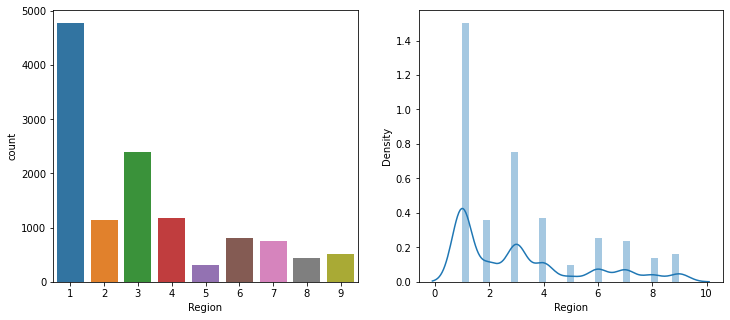

In [24]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.countplot(data = df, x = 'Region')
plt.subplot(1,2,2)
sns.distplot(df['Region'])
plt.show()

# Highest page visits and revenue generated page visits observed from Region 2
# Followed by page visits of Regions 3, 4,2 some level of page visits observed.

In [25]:
df['TrafficType'].value_counts(normalize = True)  # ', 'VisitorType

# It is observed that Traffic type 2 leading with 31% page visits followed by 1 with 20% 
# Next level observed with Traffic type 3 and 4  with 16% and 8% page visits rest of the types shown negligible visits.

2     0.317356
1     0.198783
3     0.166423
4     0.086699
13    0.059854
10    0.036496
6     0.036010
8     0.027818
5     0.021087
11    0.020032
20    0.016058
9     0.003406
7     0.003244
15    0.003082
19    0.001379
14    0.001054
18    0.000811
16    0.000243
12    0.000081
17    0.000081
Name: TrafficType, dtype: float64

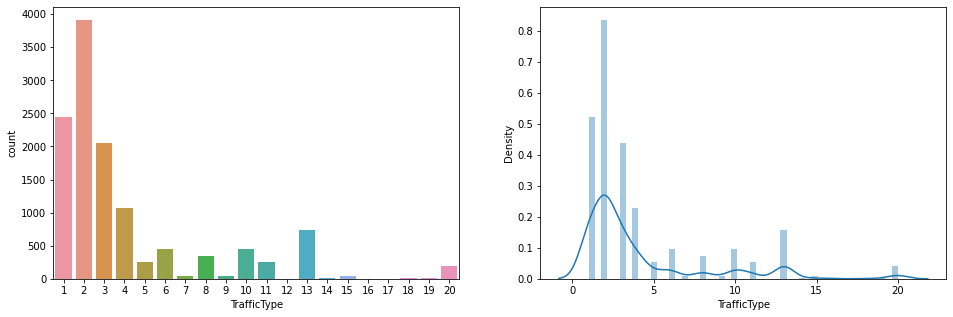

In [26]:
# Plot each feature to understand about each data
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.countplot(data = df, x = 'TrafficType')
plt.subplot(1,2,2)
sns.distplot(df['TrafficType'])
plt.show()

# Highest page visits and revenue generated page visits observed from Traffictype 2
# Followed by page visits of Traffictypes 1, 3,4 some level of page visits observed.


In [27]:
df['VisitorType'].value_counts(normalize = True)

# It is observed that Returning Visitor type customers page visits are 86% which is contributing to max revenue 
# Next level observed with New visitor and Others with 14% page visits.

Returning_Visitor    0.855718
New_Visitor          0.137388
Other                0.006894
Name: VisitorType, dtype: float64

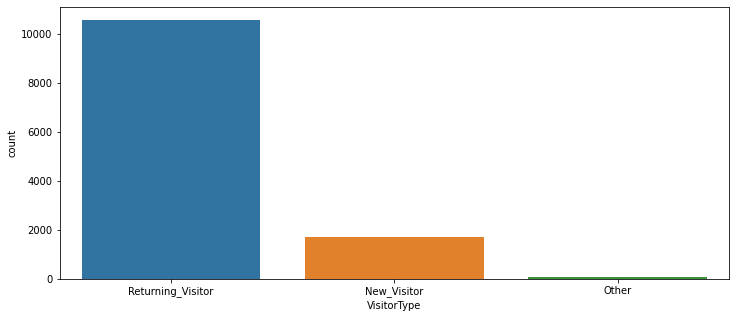

In [28]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
sns.countplot(data = df, x = 'VisitorType')
plt.show()

# Highest page visits and revenue generated page visits observed from Returning Visitor 
# Followed by page visits of New visitors.


In [29]:
df['SpecialDay (probability)'].value_counts(normalize = True)

# It is observed that May leading with 27% page visits followed by Nov with 24% 
# Next level observed with March and December with 15% and 14% page visits rest of the month negligible.

0.0    0.898540
0.6    0.028467
0.8    0.026358
0.4    0.019708
0.2    0.014436
1.0    0.012490
Name: SpecialDay (probability), dtype: float64

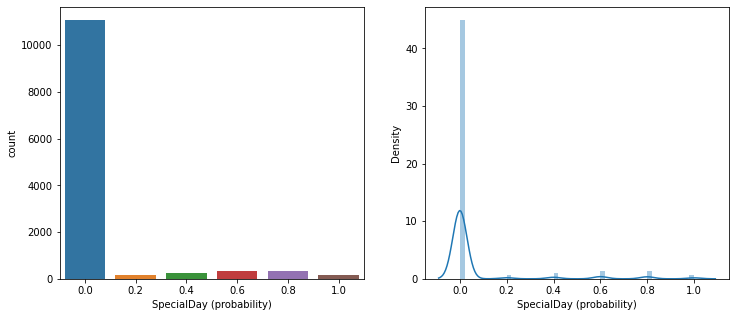

In [30]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.countplot(data = df, x = 'SpecialDay (probability)')
plt.subplot(1,2,2)
sns.distplot(df['SpecialDay (probability)'])
plt.show()

# It is observed that almost 90% pagevisits and revenue generated page visits happened on non special day
# No significant effect of special days observed on Revenue.

In [31]:
num = X.select_dtypes(include = 'number')
char = X.select_dtypes(include = 'object')
bool = X.select_dtypes(include = 'boolean')

In [32]:
num.dtypes

Administrative                int64
Administrative_Duration     float64
Informational                 int64
Informational_Duration      float64
ProductRelated                int64
ProductRelated_Duration     float64
BounceRates in %            float64
ExitRates in %              float64
PageValues                  float64
SpecialDay (probability)    float64
OperatingSystems              int64
Browser                       int64
Region                        int64
TrafficType                   int64
dtype: object

In [33]:
char.dtypes

Month          object
VisitorType    object
dtype: object

In [34]:
bool.dtypes

Weekend    bool
dtype: object

In [35]:
def unique_values(X):
    X = X.value_counts().count()
    return X
df_value_counts = pd.DataFrame(num.apply(lambda X: unique_values(X)))

# Outlier Treatment - Numerical features

# Cappling and flooring

In [36]:
num.describe(percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.85,0.9,0.99])

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates in %,ExitRates in %,PageValues,SpecialDay (probability),OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
1%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.001250,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
5%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.004568,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
10%,0.000000,0.000000,0.000000,0.000000,3.000000,36.000000,0.000000,0.007449,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000


In [37]:
def outlier_cap(X):
    X=X.clip(lower=X.quantile(0.01))
    X=X.clip(upper=X.quantile(0.99))
    return(X)


In [38]:
num = num.apply(lambda X: outlier_cap(X))

In [39]:
num.describe(percentiles=[0.01,0.05,0.10,0.25,0.50,0.75,0.85,0.9,0.99])

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates in %,ExitRates in %,PageValues,SpecialDay (probability),OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.285807,76.160053,0.485483,30.325103,30.825953,1152.751213,0.022191,0.043082,5.434185,0.061427,2.093106,2.340146,3.147364,4.069586
std,3.191369,141.779884,1.149464,104.383663,38.252586,1552.061772,0.048488,0.048588,14.843613,0.198917,0.774163,1.625229,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.001250,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
1%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.001250,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
5%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.004568,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
10%,0.000000,0.000000,0.000000,0.000000,3.000000,36.000000,0.000000,0.007449,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000


In [40]:
# Checking for null values

num.isnull().sum()

# As there are no null values so there is no need of imputation.

Administrative              0
Administrative_Duration     0
Informational               0
Informational_Duration      0
ProductRelated              0
ProductRelated_Duration     0
BounceRates in %            0
ExitRates in %              0
PageValues                  0
SpecialDay (probability)    0
OperatingSystems            0
Browser                     0
Region                      0
TrafficType                 0
dtype: int64

# Univariate Analysis of continuous variables

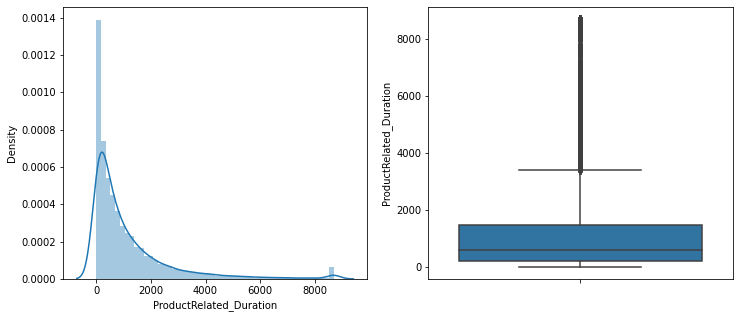

In [41]:
# Plot each feature to understand about each data  'ProductRelated_Duration', 'BounceRates in %', 'ExitRates in %', 'PageValues',
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.distplot(num['ProductRelated_Duration'])
plt.subplot(1,2,2)
sns.boxplot(y = num['ProductRelated_Duration'])
plt.show()


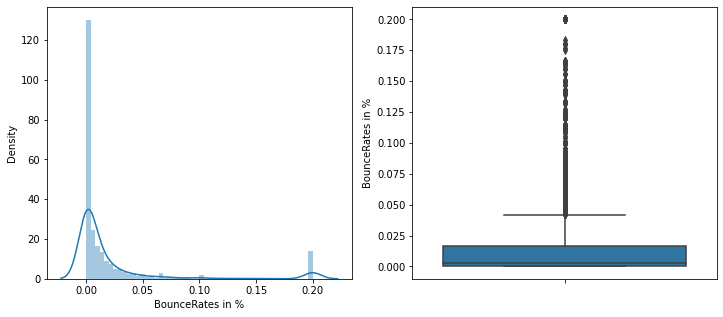

In [42]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.distplot(num['BounceRates in %'])
plt.subplot(1,2,2)
sns.boxplot(y = num['BounceRates in %'])
plt.show()


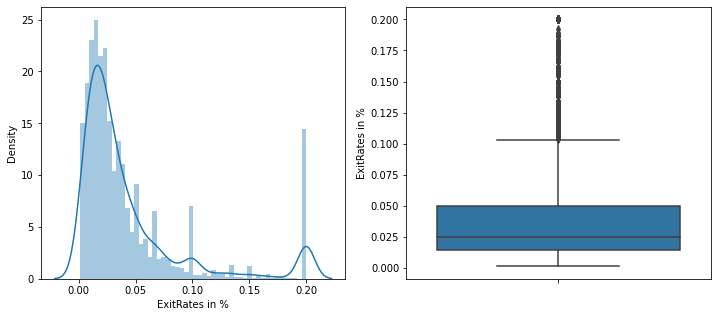

In [43]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.distplot(num['ExitRates in %'])
plt.subplot(1,2,2)
sns.boxplot(y = num['ExitRates in %'])
plt.show()


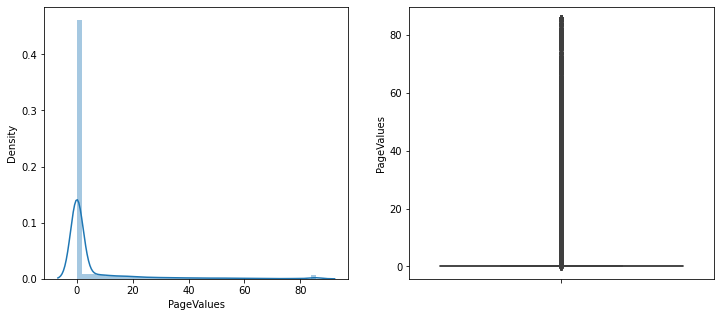

In [44]:
# Plot each feature to understand about each data
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.distplot(num['PageValues'])
plt.subplot(1,2,2)
sns.boxplot(y = num['PageValues'])
plt.show()

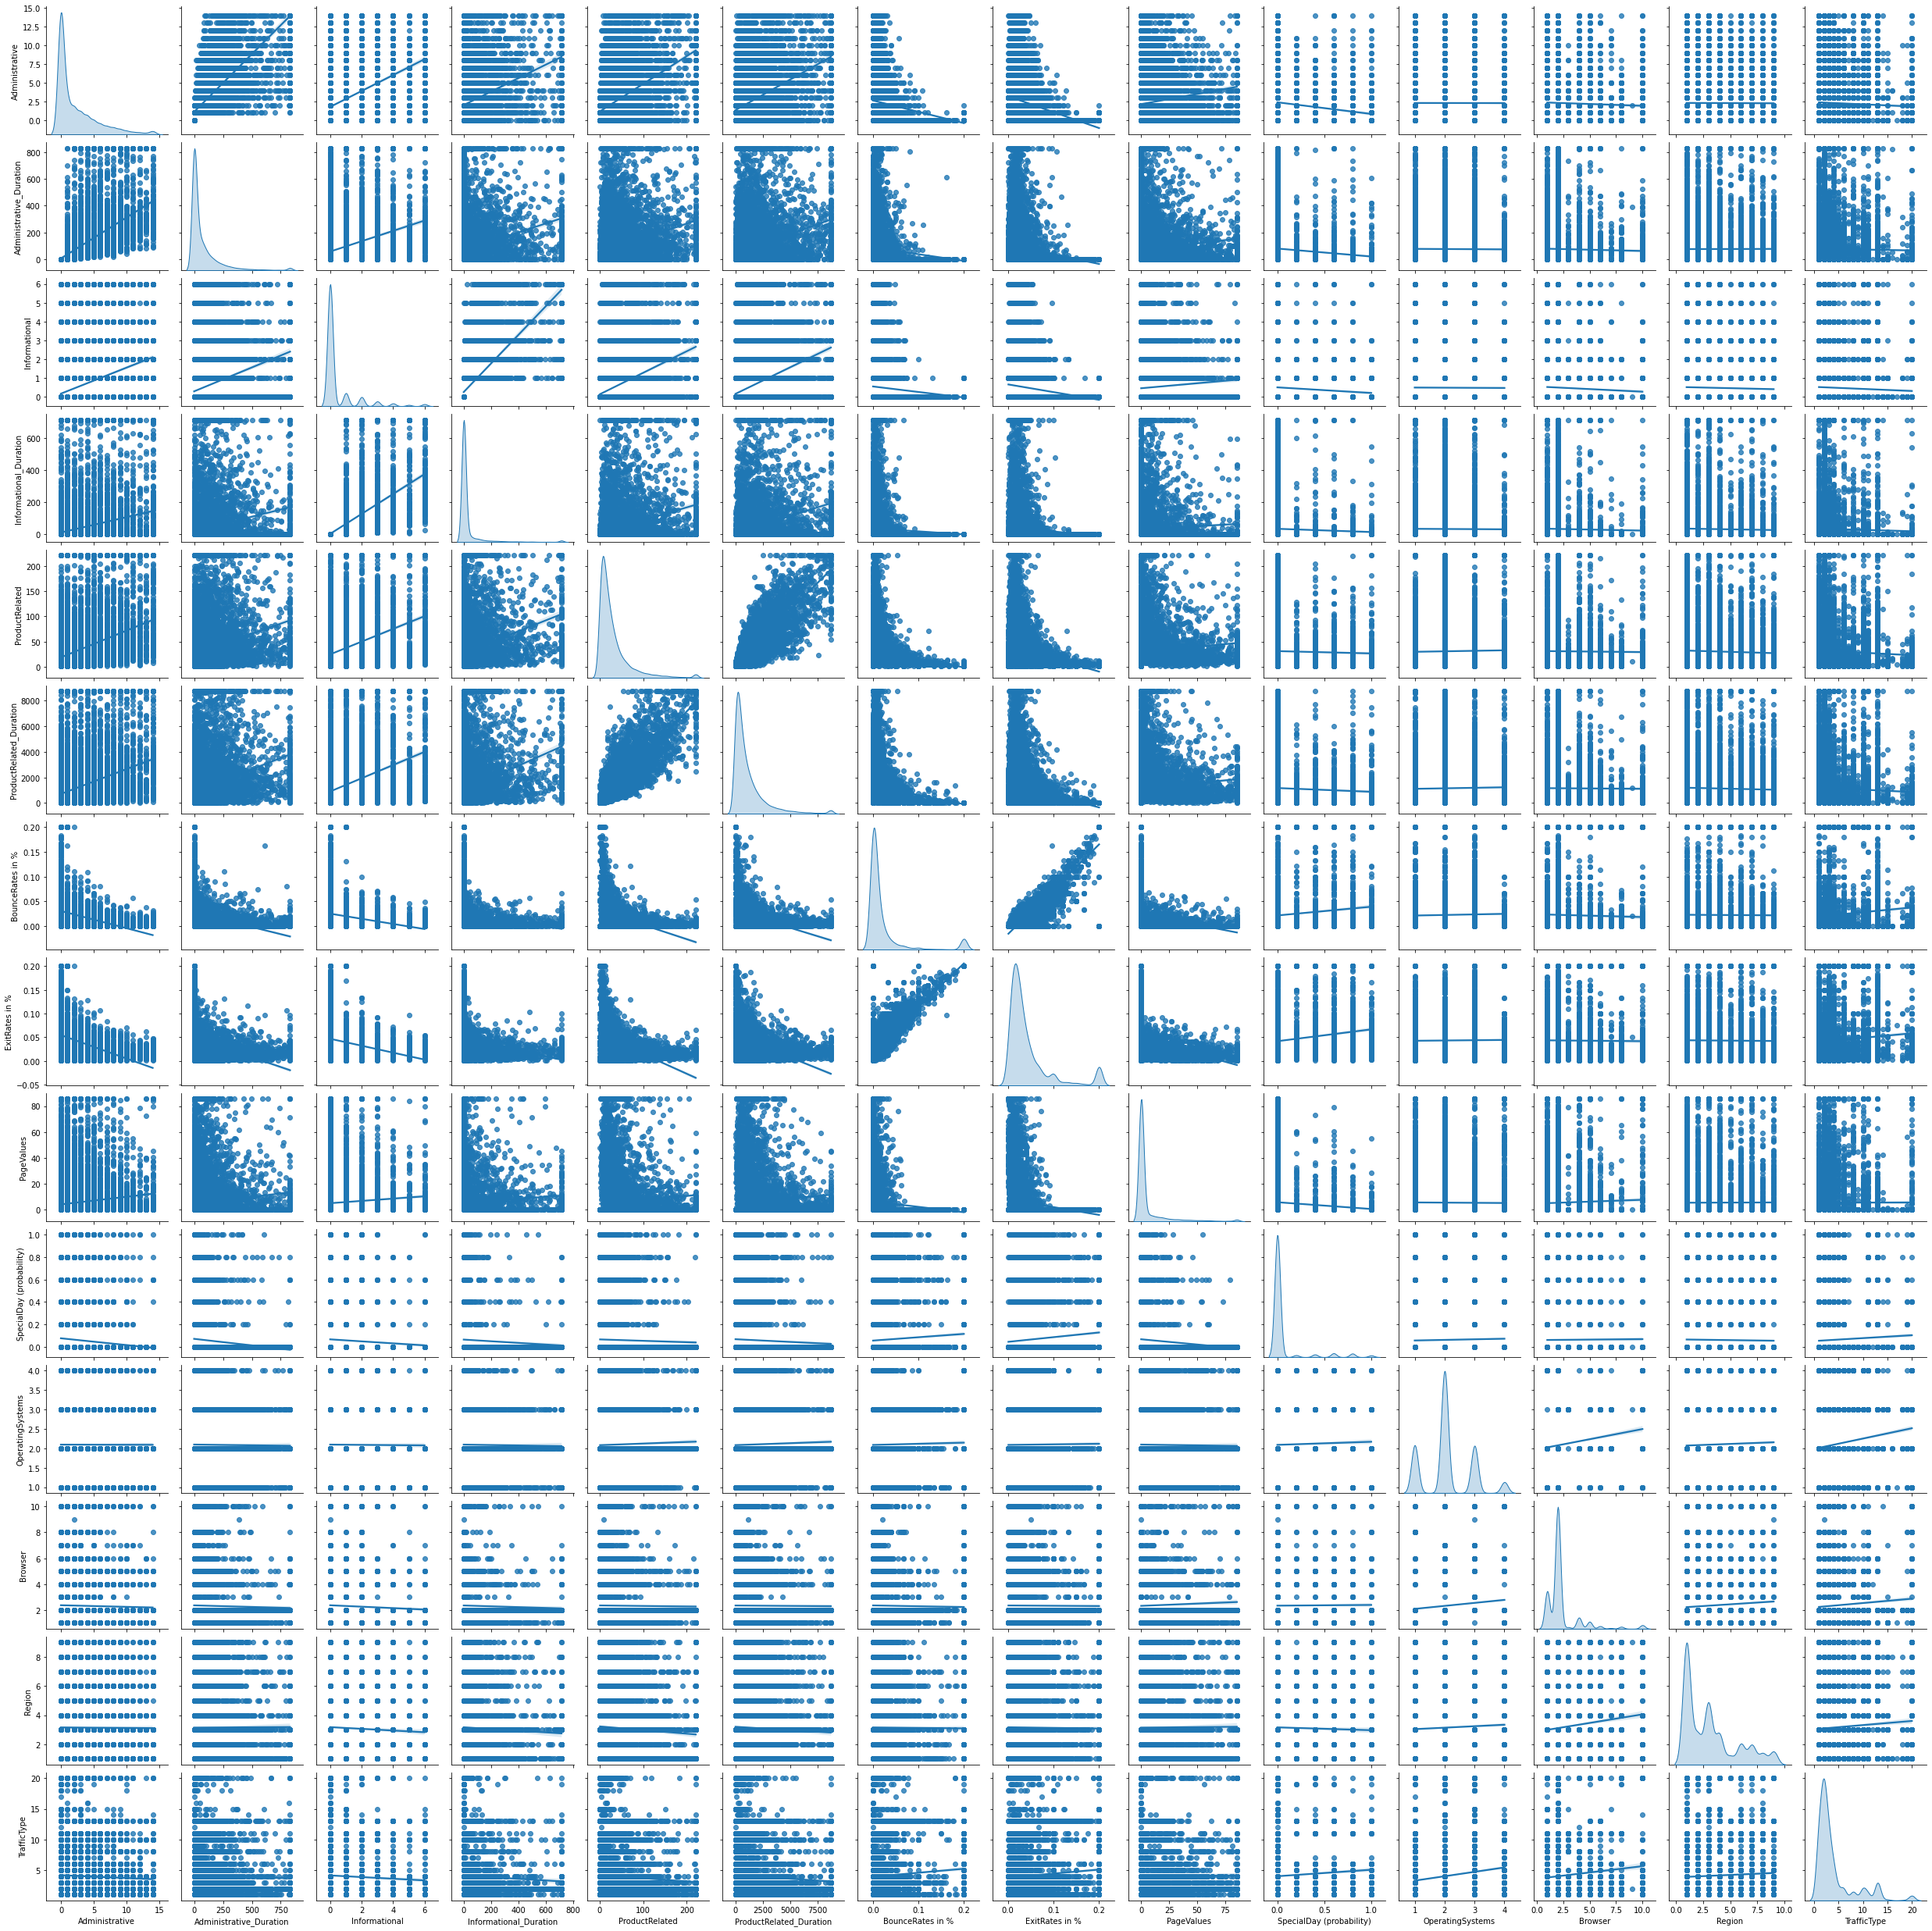

In [45]:
# plt.figure(figsize = (12,8))

sns.pairplot(num, diag_kind = 'kde', kind = 'reg')

# Bivariate Analysis of Revenue and Other variables

<AxesSubplot: xlabel='Revenue', ylabel='Administrative_Duration'>

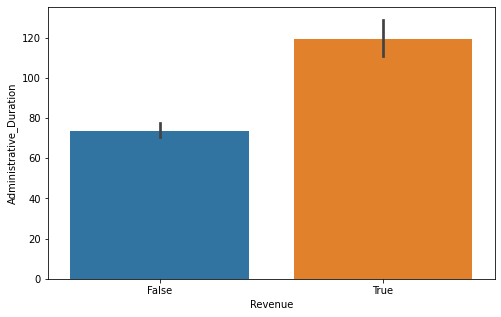

In [46]:
plt.figure(figsize = (8,5))
sns.barplot(x = 'Revenue', y = 'Administrative_Duration', data = df)

# A bar plot represents an estimate of central tendency for a numeric variable with the height of each rectangle 
# and provides some indication of the uncertainty around that estimate using error bars.
# It is also important to keep in mind that a bar plot shows only the mean (or other estimator) value.
# Below bar plot showing mean duration of Revenue generated Admin page visits is higher than non revenue visits.

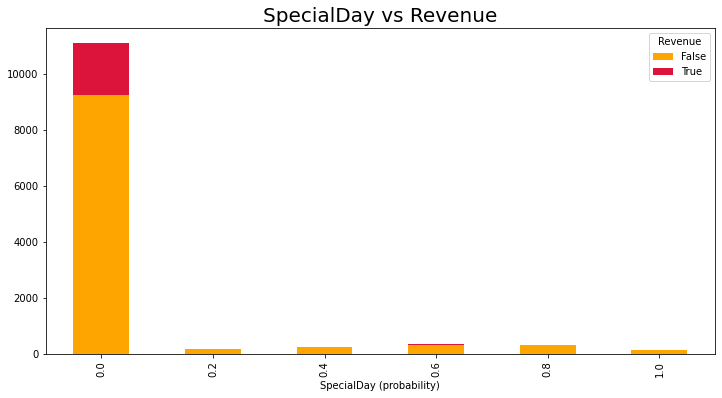

In [47]:
df1 = pd.crosstab(num['SpecialDay (probability)'], df['Revenue'])
df1.plot(kind = 'bar', stacked = True, color = ['orange', 'crimson'], figsize = (12, 6))
plt.title('SpecialDay vs Revenue', fontsize = 20 )
plt.show()

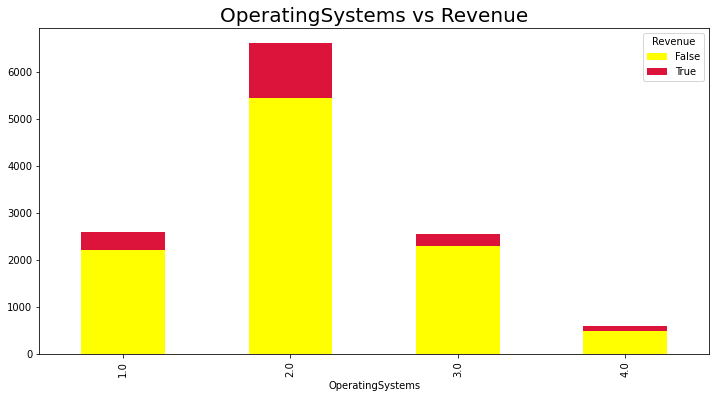

In [48]:
df1 = pd.crosstab(num['OperatingSystems'], df['Revenue'])
df1.plot(kind = 'bar', stacked = True, color = ['yellow', 'crimson'], figsize = (12, 6))
plt.title('OperatingSystems vs Revenue', fontsize = 20 )
plt.show()

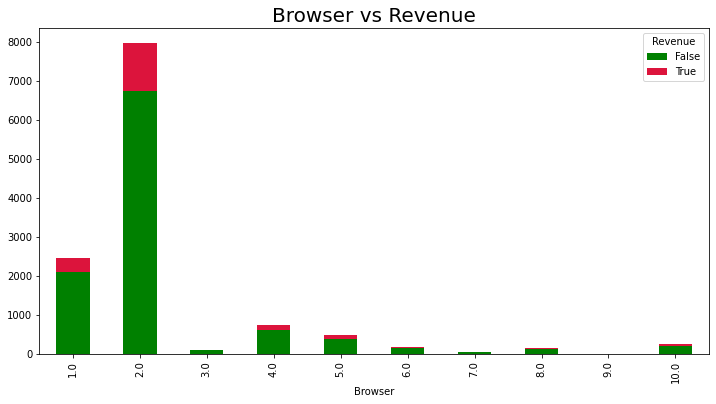

In [49]:
df1 = pd.crosstab(num['Browser'], df['Revenue'])
df1.plot(kind = 'bar', stacked = True, color = ['green', 'crimson'], figsize = (12, 6))
plt.title('Browser vs Revenue', fontsize = 20 )
plt.show()

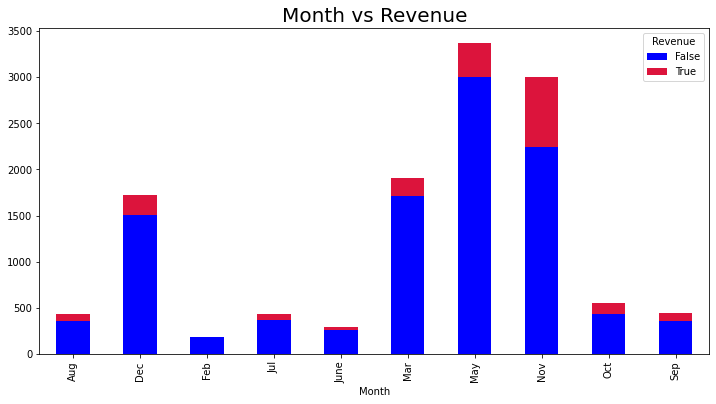

In [50]:
df1 = pd.crosstab(char['Month'], df['Revenue'])
df1.plot(kind = 'bar', stacked = True, color = ['blue', 'crimson'], figsize = (12, 6))
plt.title('Month vs Revenue', fontsize = 20 )
plt.show()

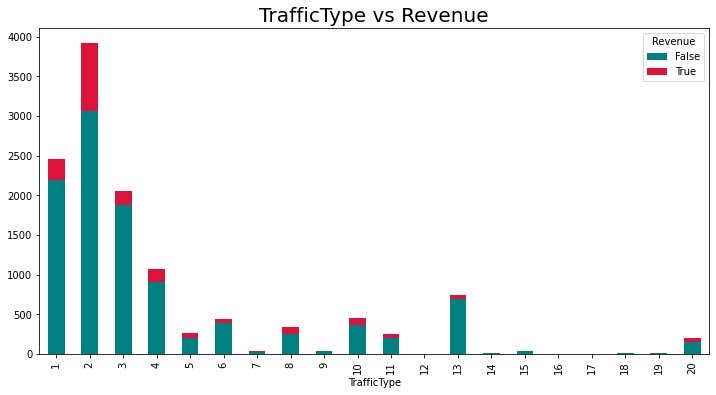

In [51]:
df1 = pd.crosstab(num['TrafficType'], df['Revenue'])
df1.plot(kind = 'bar', stacked = True, color = ['teal', 'crimson'], figsize = (12, 6))
plt.title('TrafficType vs Revenue', fontsize = 20 )
plt.show()

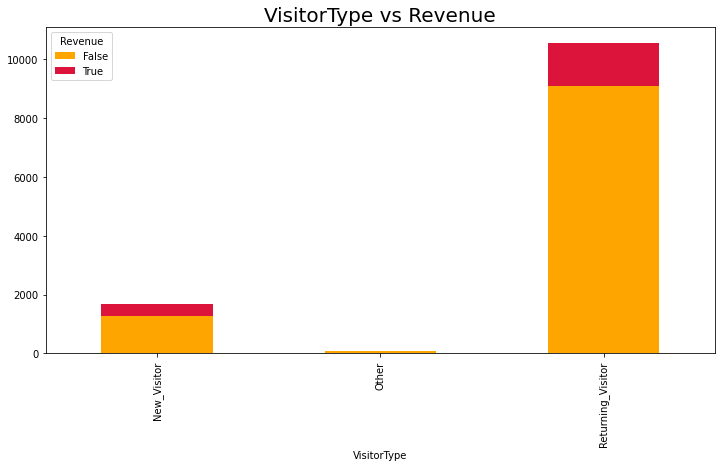

In [52]:
df1 = pd.crosstab(char['VisitorType'], df['Revenue'])
df1.plot(kind = 'bar', stacked = True, color = ['orange', 'crimson'], figsize = (12, 6))
plt.title('VisitorType vs Revenue', fontsize = 20 )
plt.show()

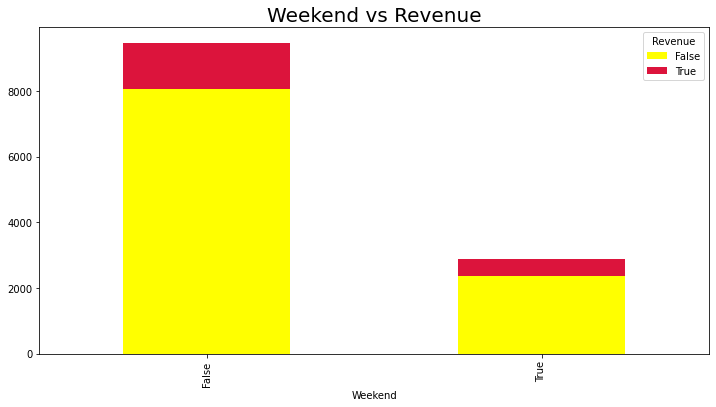

In [53]:
df1 = pd.crosstab(df['Weekend'], df['Revenue'])
df1.plot(kind = 'bar', stacked = True, color = ['yellow', 'crimson'], figsize = (12, 6))
plt.title('Weekend vs Revenue', fontsize = 20 )
plt.show()

# Data Preprocessing

# Create the Master Feature set for Model development

In [54]:
X_all = pd.concat([num, char, bool], axis = 1)

In [55]:
X_all.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates in %,ExitRates in %,PageValues,SpecialDay (probability),OperatingSystems,Browser,Region,TrafficType,Month,VisitorType,Weekend
0,0.0,0.0,0.0,0.0,1.0,0.000000,0.200000,0.200000,0.0,0.0,1.0,1.0,1,1,Feb,Returning_Visitor,False
1,0.0,0.0,0.0,0.0,2.0,64.000000,0.000000,0.100000,0.0,0.0,2.0,2.0,1,2,Feb,Returning_Visitor,False
2,0.0,0.0,0.0,0.0,1.0,0.000000,0.200000,0.200000,0.0,0.0,4.0,1.0,9,3,Feb,Returning_Visitor,False
3,0.0,0.0,0.0,0.0,2.0,2.666667,0.050000,0.140000,0.0,0.0,3.0,2.0,2,4,Feb,Returning_Visitor,False
4,0.0,0.0,0.0,0.0,10.0,627.500000,0.020000,0.050000,0.0,0.0,3.0,3.0,1,4,Feb,Returning_Visitor,True
5,0.0,0.0,0.0,0.0,19.0,154.216667,0.015789,0.024561,0.0,0.0,2.0,2.0,1,3,Feb,Returning_Visitor,False
6,0.0,0.0,0.0,0.0,1.0,0.000000,0.200000,0.200000,0.0,0.4,2.0,4.0,3,3,Feb,Returning_Visitor,False
7,1.0,0.0,0.0,0.0,1.0,0.000000,0.200000,0.200000,0.0,0.0,1.0,2.0,1,5,Feb,Returning_Visitor,True
8,0.0,0.0,0.0,0.0,2.0,37.000000,0.000000,0.100000,0.0,0.8,2.0,2.0,2,3,Feb,Returning_Visitor,False
9,0.0,0.0,0.0,0.0,3.0,738.000000,0.000000,0.022222,0.0,0.4,2.0,4.0,1,2,Feb,Returning_Visitor,False


In [56]:
X_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Administrative            12330 non-null  float64
 1   Administrative_Duration   12330 non-null  float64
 2   Informational             12330 non-null  float64
 3   Informational_Duration    12330 non-null  float64
 4   ProductRelated            12330 non-null  float64
 5   ProductRelated_Duration   12330 non-null  float64
 6   BounceRates in %          12330 non-null  float64
 7   ExitRates in %            12330 non-null  float64
 8   PageValues                12330 non-null  float64
 9   SpecialDay (probability)  12330 non-null  float64
 10  OperatingSystems          12330 non-null  float64
 11  Browser                   12330 non-null  float64
 12  Region                    12330 non-null  int64  
 13  TrafficType               12330 non-null  int64  
 14  Month 

In [57]:
# One hot encoding of object variables

X_all = pd.get_dummies(X_all)
X_all.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates in %,ExitRates in %,PageValues,SpecialDay (probability),...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0.0,0.0,0.0,0.0,1.0,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
1,0.0,0.0,0.0,0.0,2.0,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
2,0.0,0.0,0.0,0.0,1.0,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,0.0,0.0,0.0,0.0,2.0,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
4,0.0,0.0,0.0,0.0,10.0,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [58]:
X_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  float64
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  float64
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  float64
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates in %               12330 non-null  float64
 7   ExitRates in %                 12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay (probability)       12330 non-null  float64
 10  OperatingSystems               12330 non-null  float64
 11  Browser                        12330 non-null  float64
 12  Region                         12330 non-null 

In [59]:
# Label encoding of Weekend

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_all['Weekend'] = le.fit_transform(X_all['Weekend'])
X_all['Weekend'].value_counts()

0    9462
1    2868
Name: Weekend, dtype: int64

In [61]:
X_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  float64
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  float64
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  float64
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates in %               12330 non-null  float64
 7   ExitRates in %                 12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay (probability)       12330 non-null  float64
 10  OperatingSystems               12330 non-null  float64
 11  Browser                        12330 non-null  float64
 12  Region                         12330 non-null 

In [66]:
y.value_counts()

# A data set is called imbalanced if 2*minor < major.  Hence this is imbalanced dataset and need to be balanced

# using Ramdom over samplet

0    10422
1     1908
Name: Revenue, dtype: int64

There are various methods to balance a imbalanced dataset but below are worth to consider: Considered Random Over sampling method with K-fold cross validation for handling this imbalanced dataset.

1. Resample the training set i.e., by using undersamplling or over sampling methods.  These methods do random sampling from existing data set either by taking part of excessive data(for under sampling) or by adding extra random data as taken from existing data to inadequate data part to make it balanced.

2. Use of k-fold cross validation in the right way : By applying k-fold cross validation before using random over sampling method.  Only by resampling the data repeatedly, randomness can be introduced into the dataset to make sure that there won’t be an overfitting problem. If we apply k-fold cross validation after Random over sampling may lead to over fitting problem.

3. Cluster the abundant class : clustering the abundant class in r groups, with r being the number of cases in r. For each group, only the medoid (centre of cluster) is kept. The model is then trained with the rare class and the medoids only.

4. Re-sample with different ratios : data set would be fine-tuned by applying with the ratio between the rare and the abundant class. The best ratio  heavily depends on the data and the models that are used. We can try with different ratios with different models like 1:1, 2:1 etc.,

In [67]:
from sklearn.model_selection import KFold

kf = KFold()
kf.get_n_splits(X, y)
print(kf)

    
for i, (train_index, test_index) in enumerate(kf.split(X,y)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")



KFold(n_splits=5, random_state=None, shuffle=False)
Fold 0:
  Train: index=[ 2466  2467  2468 ... 12327 12328 12329]
  Test:  index=[   0    1    2 ... 2463 2464 2465]
Fold 1:
  Train: index=[    0     1     2 ... 12327 12328 12329]
  Test:  index=[2466 2467 2468 ... 4929 4930 4931]
Fold 2:
  Train: index=[    0     1     2 ... 12327 12328 12329]
  Test:  index=[4932 4933 4934 ... 7395 7396 7397]
Fold 3:
  Train: index=[    0     1     2 ... 12327 12328 12329]
  Test:  index=[7398 7399 7400 ... 9861 9862 9863]
Fold 4:
  Train: index=[   0    1    2 ... 9861 9862 9863]
  Test:  index=[ 9864  9865  9866 ... 12327 12328 12329]


In [68]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
x_ros, y_ros = ros.fit_resample(X_all, y)
print(y.value_counts())
print("############")
print(y_ros.value_counts())

0    10422
1     1908
Name: Revenue, dtype: int64
############
0    10422
1    10422
Name: Revenue, dtype: int64


In [69]:
print(x_ros.shape)
print(y_ros.shape)

(20844, 28)
(20844,)


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
x_rus, y_rus = rus.fit_resample(X, y)
print(y.value_counts())
print("############")
print(y_rus.value_counts())

In [ ]:
print(x_rus.shape)
print(y_rus.shape)

In [70]:
# Split the dataset in to Train and Test components.

from sklearn.model_selection import train_test_split, GridSearchCV

xTrain, xTest, yTrain, yTest = train_test_split(x_ros, y_ros, test_size = 0.2, random_state = 5)

In [71]:
# All the features have values in various ranges hence we need to apply scaling to bring them to comparable values.  
# Hence applying StandardScaler to do so
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
xTrain = ss.fit_transform(xTrain)
xTest = ss.transform(xTest)

In [72]:
# check the performance metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, plot_confusion_matrix, auc, roc_curve

In [73]:
# instantiate the logistic Regression model and fit the dataset in to the model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Instantiating the model
lr = LogisticRegression()

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, auc, roc_curve, roc_auc_score

In [74]:
# Model-1
classifier = LogisticRegression(C = 0.4, max_iter = 1000, solver = 'liblinear', random_state = 10)
lr = classifier.fit(xTrain, yTrain)
# Prediction
y_pred_lr = classifier.predict(xTest)
# accuracy
accuracy_LR = accuracy_score(yTest, y_pred_lr)
print(accuracy_LR)


0.8179419525065963


In [75]:
# Model - 2
from sklearn.tree import DecisionTreeClassifier
classifier2 = DecisionTreeClassifier(random_state = 10)
dt = classifier2.fit(xTrain, yTrain)
# predict
y_pred_dt = classifier2.predict(xTest)
# accuracy
accuracy_dt = accuracy_score(yTest, y_pred_dt)
print(accuracy_dt)

0.9573039098105062


In [76]:
# Model - 3
from sklearn.ensemble import RandomForestClassifier
classifier3 = RandomForestClassifier(random_state = 10)
rfi = classifier3.fit(xTrain, yTrain)
# prediction
y_pred_rfi = classifier3.predict(xTest)
# accuracy
accuracy_rfi = accuracy_score(yTest, y_pred_rfi)
print(accuracy_rfi)

0.9668985368193811


In [77]:
# Model - 4
from sklearn.ensemble import RandomForestClassifier
classifier4 = RandomForestClassifier(criterion = 'entropy', random_state = 10)
rfe = classifier4.fit(xTrain, yTrain)
# prediction
y_pred_rfe = classifier4.predict(xTest)
# accuracy
accuracy_rfe = accuracy_score(yTest, y_pred_rfe)
print(accuracy_rfe)

0.9659390741184937


In [78]:
# Model - 5
from sklearn.svm import SVC
model_svm = SVC(random_state = 10)
SVM = model_svm.fit(xTrain, yTrain)
# prediction
y_pred_svm = model_svm.predict(xTest)
# accuracy
accuracy_svm = accuracy_score(yTest, y_pred_svm)
print(accuracy_svm)

0.8642360278244183


             Method Used  Accuracy
0    Logistic Regression  0.817942
1          Decision Tree  0.957304
2     Random Forest Gini  0.966899
3  Random Forest entropy  0.965939
4         Support Vector  0.864236
5      Voting Classifier  0.961382
AxesSubplot(0.125,0.125;0.775x0.755)


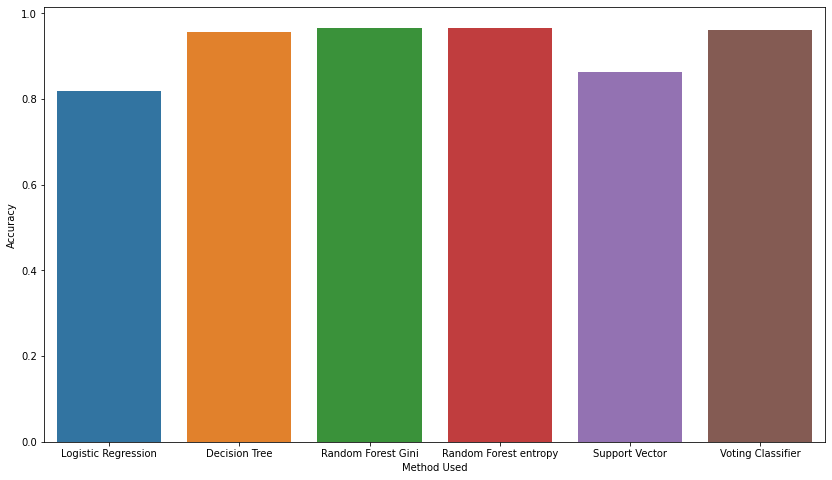

In [79]:
# combine all the models using voting classifier model

from sklearn.ensemble import VotingClassifier
model_evc = VotingClassifier(estimators = [('lr',lr),('dt',dt),('rfi',rfi),('rfe',rfe),('SVC', SVM)])
evc = model_evc.fit(xTrain, yTrain)
y_pred_evc = model_evc.predict(xTest)
accuracy_evc = accuracy_score(yTest, y_pred_evc)

list1 = ['Logistic Regression', 'Decision Tree', 'Random Forest Gini', 'Random Forest entropy', 'Support Vector', 'Voting Classifier']

list2 = [accuracy_LR, accuracy_dt, accuracy_rfi, accuracy_rfe, accuracy_svm, accuracy_evc]

list3 = [classifier, classifier2, classifier3, classifier4, model_svm, model_evc]

df_accuracy = pd.DataFrame({'Method Used':list1, 'Accuracy':list2})
print(df_accuracy)

plt.figure(figsize = (14,8))
charts = sns.barplot(x = 'Method Used', y = 'Accuracy', data = df_accuracy)
print(charts)
                

In [80]:
import pandas as pd
feature_importances=pd.DataFrame(classifier3.feature_importances_,
                                 index=X_all.columns,
                                 columns=['importance']).sort_values('importance',ascending=False)
feature_importances

,importance
PageValues,0.381310
ProductRelated_Duration,0.091788
ExitRates in %,0.089217
ProductRelated,0.067117
BounceRates in %,0.057214
Administrative_Duration,0.046151
Administrative,0.039228
Month_Nov,0.029544
TrafficType,0.028132
Region,0.026786


In [81]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix


# evaluation
# Random Forest
y_pred_lr_train = classifier.predict(xTrain)
y_pred_lr = classifier.predict(xTest)

y_pred_dt_train = classifier2.predict(xTest)
y_pred_dt = classifier2.predict(xTest)

y_pred_rfe_train = classifier4.predict(xTrain)
y_pred_rfe = classifier4.predict(xTest)

y_pred_svm_train = model_svm.predict(xTrain)
y_pred_svm = model_svm.predict(xTest)

y_pred_evc_train = model_evc.predict(xTrain)
y_pred_evc = model_evc.predict(xTest)


In [82]:
print("Accuracy:",metrics.accuracy_score(yTest, y_pred_lr))
print("Precision",metrics.precision_score(yTest,y_pred_lr))
print("Recall",metrics.recall_score(yTest,y_pred_lr))
print("f1_score",metrics.f1_score(yTest,y_pred_lr))

Accuracy: 0.8179419525065963
Precision 0.8583554376657825
Recall 0.7668246445497631
f1_score 0.8100125156445558


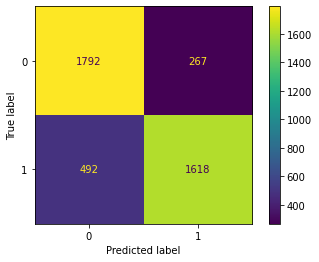

In [83]:
metrics.plot_confusion_matrix(lr,xTest,yTest)

In [84]:
print("Accuracy:",metrics.accuracy_score(yTest, y_pred_dt))
print("Precision",metrics.precision_score(yTest,y_pred_dt))
print("Recall",metrics.recall_score(yTest,y_pred_dt))
print("f1_score",metrics.f1_score(yTest,y_pred_dt))

Accuracy: 0.9573039098105062
Precision 0.9263018534863195
Recall 0.9947867298578199
f1_score 0.9593235831809873


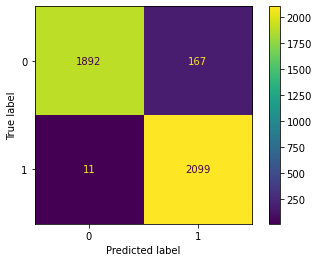

In [85]:
metrics.plot_confusion_matrix(dt,xTest,yTest)

In [86]:
print("Accuracy:",metrics.accuracy_score(yTest, y_pred_rfe))
print("Precision",metrics.precision_score(yTest,y_pred_rfe))
print("Recall",metrics.recall_score(yTest,y_pred_rfe))
print("f1_score",metrics.f1_score(yTest,y_pred_rfe))

Accuracy: 0.9659390741184937
Precision 0.9400715563506261
Recall 0.9962085308056872
f1_score 0.9673262770363552


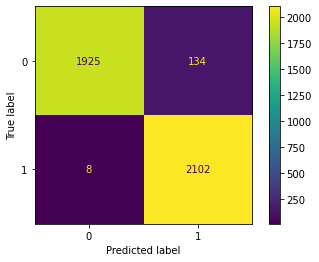

In [87]:
metrics.plot_confusion_matrix(rfe,xTest,yTest)

In [88]:
print("Accuracy:",metrics.accuracy_score(yTest, y_pred_svm))
print("Precision",metrics.precision_score(yTest,y_pred_svm))
print("Recall",metrics.recall_score(yTest,y_pred_svm))
print("f1_score",metrics.f1_score(yTest,y_pred_svm))

Accuracy: 0.8642360278244183
Precision 0.8736689254598258
Recall 0.8554502369668247
f1_score 0.8644636015325671


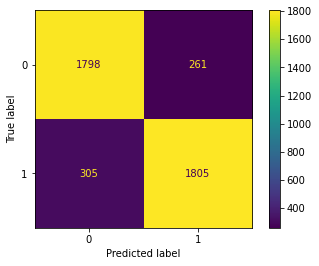

In [89]:
metrics.plot_confusion_matrix(SVM,xTest,yTest)

In [90]:
print("Accuracy:",metrics.accuracy_score(yTest, y_pred_evc))
print("Precision",metrics.precision_score(yTest,y_pred_evc))
print("Recall",metrics.recall_score(yTest,y_pred_evc))
print("f1_score",metrics.f1_score(yTest,y_pred_evc))

Accuracy: 0.961381626289278
Precision 0.9325343985796716
Recall 0.9957345971563981
f1_score 0.9630987852395141


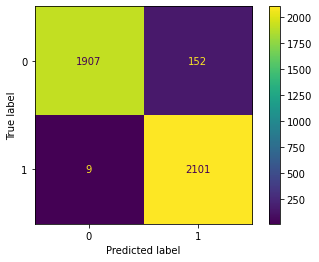

In [91]:
metrics.plot_confusion_matrix(evc,xTest,yTest)

In [92]:
print(classification_report(yTest, y_pred_lr ))
print('#########################################')
print(classification_report(yTest, y_pred_dt ))
print('#########################################')
print(classification_report(yTest, y_pred_rfe ))
print('#########################################')
print(classification_report(yTest, y_pred_svm ))
print('#########################################')
print(classification_report(yTest, y_pred_evc))



              precision    recall  f1-score   support

           0       0.78      0.87      0.83      2059
           1       0.86      0.77      0.81      2110

    accuracy                           0.82      4169
   macro avg       0.82      0.82      0.82      4169
weighted avg       0.82      0.82      0.82      4169

#########################################
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      2059
           1       0.93      0.99      0.96      2110

    accuracy                           0.96      4169
   macro avg       0.96      0.96      0.96      4169
weighted avg       0.96      0.96      0.96      4169

#########################################
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      2059
           1       0.94      1.00      0.97      2110

    accuracy                           0.97      4169
   macro avg       0.97      0.97      0.97 

In [93]:
y_pred_prob = rfe.predict_proba(xTest)[::,1]
y_pred_prob

array([1.  , 0.07, 0.02, ..., 1.  , 0.03, 1.  ])

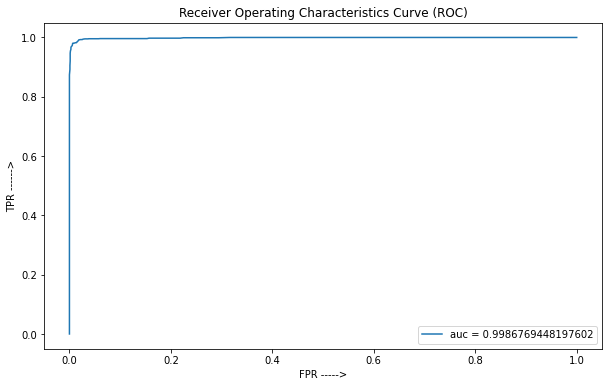

In [94]:
# metrics.roc_curve returns three outputs, fpr, tpr and different thresholds
fpr, tpr, threshold = roc_curve(yTest, y_pred_prob)

auc = roc_auc_score(yTest, y_pred_prob)

# plotting AUC curve
plt.figure(figsize = (10,6))
plt.plot(fpr, tpr, label = 'auc = '+str(auc))
plt.title('Receiver Operating Characteristics Curve (ROC)')
plt.legend(loc = 4)
plt.xlabel('FPR ----->')
plt.ylabel('TPR ------>')
plt.show()

In [95]:
precision = ['Random Forest(entropy)', 'precision', 1.00, 0.94]
recall = ['Random Forest(entropy)', 'recall', 0.94, 1.00]
f1_score = ['Random Forest(entropy)', 'f1_score', 0.97, 0.97 ]
precision2 = ['Support Vector Machine', 'precision', 0.85, 0.88 ]
recall2 = ['Support Vector Machine', 'recall', 0.88, 0.84 ]
f1_score2 = ['Support Vector Machine', 'f1_score', 0.87, 0.86 ]
precision3 = ['Voting Classifier', 'precision', 1.00, 0.93 ]
recall3 = ['Voting Classifier', 'recall', 0.92, 1.00 ]
f1_score3 = ['Voting Classifier', 'f1_score', 0.96, 0.96 ]
precision4 = ['Logistic Regression', 'precision', 0.78, 0.86]
recall4 = ['Logistic Regression', 'recall', 0.87, 0.76]
f1_score4 = ['Logistic Regression', 'f1_score', 0.82, 0.80 ]
precision5 = ['Decision Tree', 'precision', 1.00, 0.92 ]
recall5 = ['Decision Tree', 'recall', 0.91, 1.00 ]
f1_score5 = ['Decision Tree', 'f1_score', 0.95, 0.95 ]
table = pd.DataFrame([precision, precision2, precision3, precision4, precision5, recall, recall2, recall3, recall4, recall5, f1_score, f1_score2, f1_score3, f1_score4, f1_score5])
table.columns = ['model_name', 'metrics', 'Is_Revenue(False)', 'Is_Revenue(True)']
table
 

,model_name,metrics,Is_Revenue(False),Is_Revenue(True)
0,Random Forest(entropy),precision,1.00,0.94
1,Support Vector Machine,precision,0.85,0.88
2,Voting Classifier,precision,1.00,0.93
3,Logistic Regression,precision,0.78,0.86
4,Decision Tree,precision,1.00,0.92
5,Random Forest(entropy),recall,0.94,1.00
6,Support Vector Machine,recall,0.88,0.84
7,Voting Classifier,recall,0.92,1.00
8,Logistic Regression,recall,0.87,0.76
9,Decision Tree,recall,0.91,1.00
